# 02 · Parameter Estimation
**Based on:** *Estimation in Information Fusion* — W. Dale Blair (GTRI), FUSION Boot Camp 2026, part 1.

### Lecture outline
❑ Introduction ❑ **Parametric estimation** ❑ Stochastic state estimation ❑ Target tracking ❑ Concluding remarks

### The key distinction
* **Parameter** — a **time-invariant** but unknown quantity (e.g. the position of a stationary target, a sensor bias). We estimate it from noisy measurements.
* **State** — a quantity that **evolves in time** (position/velocity/acceleration), usually linked by differential equations → topic of notebook 03.

General measurement model: $z_j = h(x) + w_j$, and we seek an estimator $\hat{x}(Z_k)\approx x$ from the measurement set $Z_k=\{z_j\}_{j=1}^k$.

## A. Families of estimators

| Estimator | Definition | When to use |
|-----------|------------|-------------|
| **ML** (Maximum Likelihood) | $\hat{x}_{ML}=\arg\max_x p(Z\mid x)$ | no prior information on $x$ |
| **MAP** (Maximum A Posteriori) | $\hat{x}_{MAP}=\arg\max_x p(x\mid Z)\propto p(Z\mid x)\,p(x)$ | a prior $p(x)$ is available |
| **MMSE** (Min. Mean Squared Error) | $\hat{x}_{MMSE}=E[x\mid Z]$ | minimize $E\|x-\hat{x}\|^2$ |
| **LSE** (Least Squares) | $\hat{x}=\arg\min_x \sum_j (z_j-h_j(x))^2$ | no probabilistic model |
| **WLSE** (Weighted LSE) | $\hat{x}=\arg\min_x \sum_j (z_j-h_j(x))^2/\sigma_j^2$ | unequal measurement variances |

For independent Gaussian noise, **ML ≡ WLSE** (weights = $1/\sigma_j^2$), and when the variances are equal **ML ≡ LSE**.

## B. LSE for a linear system
When $z = Hx + w$ (a batch of $N$ measurements), the least-squares solution is:

$$\hat{x} = (H^TH)^{-1}H^Tz, \qquad P_{\hat{x}} = \sigma_w^2 (H^TH)^{-1}$$

and for WLSE with a measurement covariance matrix $R$:

$$\hat{x} = (H^TR^{-1}H)^{-1}H^TR^{-1}z, \qquad P_{\hat{x}} = (H^TR^{-1}H)^{-1}$$

**Slide example:** 11 measurements of a stationary target with $\sigma_w=2$ m. Here $h(x)=x$, i.e. $H=\mathbf{1}$, 
and the solution reduces to the **mean**: $\hat{x}=\frac{1}{N}\sum z_j$ with variance $\sigma_w^2/N$.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
rng = np.random.default_rng(1)

def lse_linear(H, z, R=None):
    """LSE / WLSE for a linear system z = H x + w. R = covariance matrix (optional)."""
    H = np.atleast_2d(H); z = np.asarray(z, float).reshape(-1, 1)
    if R is None:
        G = np.linalg.inv(H.T @ H) @ H.T
        xhat = G @ z
        return xhat.ravel(), np.linalg.inv(H.T @ H)   # multiply by sigma^2 for P
    Ri = np.linalg.inv(R)
    P = np.linalg.inv(H.T @ Ri @ H)
    xhat = P @ H.T @ Ri @ z
    return xhat.ravel(), P

# Stationary-target example (11 measurements, sigma_w = 2)
true_x = 100.0; sigma_w = 2.0; N = 11
z = true_x + sigma_w * rng.standard_normal(N)
H = np.ones((N, 1))
xhat, M = lse_linear(H, z)
P = sigma_w**2 * M
print(f'LSE estimate = {xhat[0]:.3f} m   (truth = {true_x})')
print(f'estimate variance = {P[0,0]:.3f} = sigma_w^2/N = {sigma_w**2/N:.3f}')
print(f'standard deviation = {np.sqrt(P[0,0]):.3f} m')

LSE estimate = 100.414 m   (truth = 100.0)
estimate variance = 0.364 = sigma_w^2/N = 0.364
standard deviation = 0.603 m


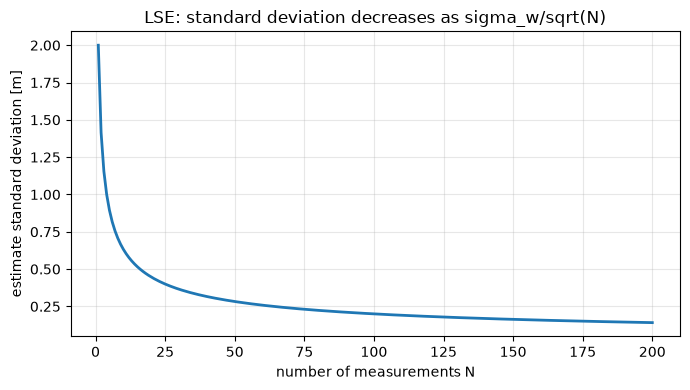

In [2]:
# Convergence: the standard deviation decreases as 1/sqrt(N)
Ns = np.arange(1, 201)
std_theory = sigma_w / np.sqrt(Ns)
plt.figure(figsize=(7,4))
plt.plot(Ns, std_theory, 'C0', lw=2)
plt.xlabel('number of measurements N'); plt.ylabel('estimate standard deviation [m]')
plt.title('LSE: standard deviation decreases as sigma_w/sqrt(N)'); plt.grid(alpha=.3)
plt.tight_layout(); plt.show()

## C. The Cramér–Rao Lower Bound (CRLB)
The CRLB is a lower bound on the variance of **any** unbiased estimator:

$$\operatorname{Var}(\hat{x}) \ge \frac{1}{I(x)}, \qquad I(x) = -E\!\left[\frac{\partial^2 \ln p(Z\mid x)}{\partial x^2}\right]$$

where $I(x)$ is the **Fisher Information**. An estimator that attains the bound is called *efficient*. 
For $N$ independent Gaussian measurements of a stationary parameter, $I(x)=N/\sigma_w^2$, so 
$\operatorname{Var}(\hat{x})\ge \sigma_w^2/N$ — and LSE/ML attains equality (efficient).

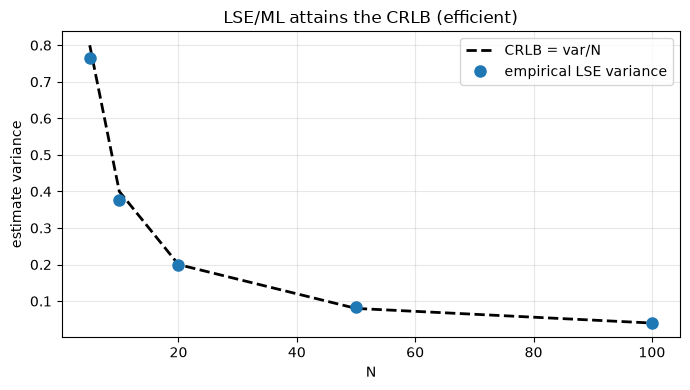

In [3]:
# Monte-Carlo verification: does LSE reach the CRLB?
sigma_w = 2.0
Ns = [5, 10, 20, 50, 100]
mc = 5000
emp_var, crlb = [], []
for N in Ns:
    ests = []
    for _ in range(mc):
        z = true_x + sigma_w*rng.standard_normal(N)
        ests.append(z.mean())
    emp_var.append(np.var(ests))
    crlb.append(sigma_w**2 / N)

plt.figure(figsize=(7,4))
plt.plot(Ns, crlb, 'k--', lw=2, label='CRLB = var/N')
plt.plot(Ns, emp_var, 'o', ms=8, label='empirical LSE variance')
plt.xlabel('N'); plt.ylabel('estimate variance'); plt.legend(); plt.grid(alpha=.3)
plt.title('LSE/ML attains the CRLB (efficient)'); plt.tight_layout(); plt.show()

## D. ML estimation — a nonlinear example
Blair demonstrates an ML estimator on a nonlinear model of the form $z_j = \cos(2\pi w x) + w_j$. 
Here the likelihood is non-convex and the maximum must be found numerically (grid search / optimization). 
Below we use a simpler nonlinear model to estimate a **frequency** $f$ from a sampled signal: $z_j = \cos(2\pi f\, t_j) + w_j$.

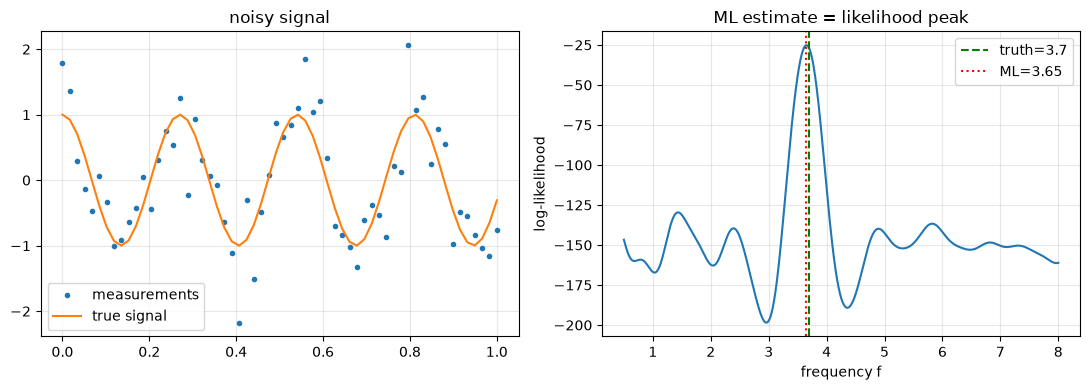

ML frequency estimate = 3.652  (truth = 3.7)


In [4]:
# ML frequency estimation by scanning the log-likelihood
f_true = 3.7; sigma = 0.5
t = np.linspace(0, 1, 60)
z = np.cos(2*np.pi*f_true*t) + sigma*rng.standard_normal(t.size)

f_grid = np.linspace(0.5, 8, 1500)
# Gaussian log-likelihood: -0.5/sigma^2 * sum (z - cos(2 pi f t))^2  (+const)
ll = np.array([-0.5/sigma**2 * np.sum((z - np.cos(2*np.pi*f*t))**2) for f in f_grid])
f_ml = f_grid[np.argmax(ll)]

fig, ax = plt.subplots(1, 2, figsize=(11,4))
ax[0].plot(t, z, '.', label='measurements'); ax[0].plot(t, np.cos(2*np.pi*f_true*t), label='true signal')
ax[0].set_title('noisy signal'); ax[0].legend(); ax[0].grid(alpha=.3)
ax[1].plot(f_grid, ll); ax[1].axvline(f_true, color='g', ls='--', label=f'truth={f_true}')
ax[1].axvline(f_ml, color='r', ls=':', label=f'ML={f_ml:.2f}')
ax[1].set_xlabel('frequency f'); ax[1].set_ylabel('log-likelihood'); ax[1].set_title('ML estimate = likelihood peak')
ax[1].legend(); ax[1].grid(alpha=.3); plt.tight_layout(); plt.show()
print(f'ML frequency estimate = {f_ml:.3f}  (truth = {f_true})')

## E. Sensor bias estimation and observability
Blair devotes several slides to estimating a sensor **bias**. The key lesson: with a single sensor, 
position $x$ and bias $b$ are **not separately observable** — the measurement is always $z=x+b+w$, and any split 
between $x$ and $b$ fits the same data. The matrix $H^TH$ becomes singular and "the estimate cannot be computed".

**The remedy:** adding another information source (a second sensor, or a calibration/reference target whose 
position is known) makes the problem observable — and this is exactly where **fusion** enters: combining 
sources resolves unobservability.

In [5]:
# Demonstration: single sensor -> H^T H singular (x and b not separately observable)
# Measurement: z = x + b + w. Unknowns: [x, b].
N = 10
H_single = np.hstack([np.ones((N,1)), np.ones((N,1))])  # the two columns are identical!
print('rank(H) (single sensor):', np.linalg.matrix_rank(H_single), 'of 2 -> singular, cannot separate x and b')

# Remedy: a calibration target at known position x0=0 (b alone observable) + an unknown target
# the sensor measures the calibration target and the target: z_cal = 0 + b + w ; z_tgt = x + b + w
x_true, b_true, sw = 50.0, 4.0, 1.0
m = 200
z_cal = 0 + b_true + sw*rng.standard_normal(m)
z_tgt = x_true + b_true + sw*rng.standard_normal(m)
# unknowns theta=[x, b]; two equations: z_cal = b ; z_tgt = x + b
Hc = np.array([[0.,1.],[1.,1.]])
zc = np.array([z_cal.mean(), z_tgt.mean()])
theta, _ = lse_linear(Hc, zc, R=np.eye(2)*(sw**2/m))
print(f'with a calibration target:  x_hat = {theta[0]:.2f} (truth {x_true}),  b_hat = {theta[1]:.2f} (truth {b_true})')
print('-> an additional information source (fusion) made the problem observable.')

rank(H) (single sensor): 1 of 2 -> singular, cannot separate x and b
with a calibration target:  x_hat = 50.00 (truth 50.0),  b_hat = 3.90 (truth 4.0)
-> an additional information source (fusion) made the problem observable.


## Summary
* **ML / MAP / MMSE / LSE / WLSE** — the family of estimators; under Gaussian noise they coincide (ML≡WLSE, and equal-variance ⇒ ≡LSE).
* **Linear LSE:** $\hat{x}=(H^TR^{-1}H)^{-1}H^TR^{-1}z$ with variance $(H^TR^{-1}H)^{-1}$.
* **The CRLB** sets the floor on variance; LSE/ML is *efficient* for a stationary target.
* **Observability:** bias and position are inseparable for a single sensor — **fusion** of sources resolves this.

In notebook 03 we move from a **stationary** parameter to a state that **evolves in time** — leading to the Kalman filter.